# 深度学习课程设计报告

## 一、封面

- **课程名称**：深度学习B
- **设计题目**：基于自建 CNN 和 ResNet18 迁移学习的人脸表情识别系统
- **姓    名**：赵果剑
- **学    号**：20234080327
- **班    级**：23数据03班
- **指导教师**：丁平尖
- **提交日期**：2026 年 6 月 12 日

## 二、摘要

人脸表情识别是计算机视觉中的经典分类问题。本设计在 FER2013 数据集上，从零训练了一个自建 CNN 模型，并与 ResNet18 迁移学习进行对比，实现 7 类基本表情的识别。

主要工作包括：(1) 设计了一个包含 5 层卷积的 CNN 基线模型，从零开始训练 20 个 epoch，测试集准确率约 63%。(2) 使用预训练 ResNet18 进行迁移学习（全模型微调 15 个 epoch），测试集准确率约 69%。(3) 详细对比了两种模型在各类别上的表现差异，分析了自建 CNN 和预训练模型的优劣。(4) 将模型封装为推理服务，支持图片识别、摄像头实时检测和 Web 交互。

项目代码已上传至 GitHub：https://github.com/Xiao-guoA/Deep-Learning/tree/main/facial-expression-recognition

## 三、问题定义与需求分析

### 3.1 项目背景

面部表情是人类非语言交流的重要方式。自动识别表情在教育（分析学生注意力）、驾驶监控（检测疲劳）、人机交互（调整反馈）等场景有实用价值。从深度学习课程角度，表情识别适合作为分类任务来实践卷积神经网络、迁移学习、数据增强等核心知识点。

### 3.2 问题定义

- **输入**：48×48 像素的灰度人脸图像
- **输出**：7 类表情之一（Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral）
- **任务类型**：图像分类
- **评价指标**：准确率 (Accuracy)、混淆矩阵 (Confusion Matrix)、各类别 Precision/Recall/F1

### 3.3 技术路线

本设计采用两条路线进行对比：
1. **自建 CNN 基线**：从零设计卷积神经网络，仅靠 FER2013 训练集训练，不依赖任何预训练权重。这能直接展示深度学习中的卷积、池化、批归一化、Dropout 等核心概念。
2. **ResNet18 迁移学习**：使用在 ImageNet 上预训练的 ResNet18，在 FER2013 上进行全模型微调。展示迁移学习的实际效果。

两者的对比分析是本设计的核心——自建模型能让老师看到我对深度学习原理的理解，迁移学习则展示了我对实用技术的掌握。

## 四、数据集说明与预处理

### 4.1 FER2013 数据集

FER2013 来自 2013 年 ICML 举办的 Kaggle 竞赛，由 Google 搜索引擎收集的人脸表情图片经自动化裁剪和对齐后生成。共 35,887 张 48×48 灰度图，划分为 7 类：

| 表情 | 标签 | 训练集 | 验证集 | 测试集 | 总计 |
|------|------|--------|--------|--------|------|
| Angry | 0 | 3,995 | 467 | 491 | 4,953 |
| Disgust | 1 | 436 | 55 | 56 | 547 |
| Fear | 2 | 4,097 | 496 | 528 | 5,121 |
| Happy | 3 | 7,215 | 895 | 879 | 8,989 |
| Sad | 4 | 4,845 | 653 | 579 | 6,077 |
| Surprise | 5 | 3,171 | 415 | 416 | 4,002 |
| Neutral | 6 | 4,950 | 607 | 641 | 6,198 |
| **合计** | | **28,709** | **3,588** | **3,590** | **35,887** |

Disgust 只有 547 张，存在明显的类别不平衡，这会影响模型在该类别上的表现。

总样本数: 35887


C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\801360589.py:37: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\801360589.py:37: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\801360589.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\801360589.py:37: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\801360589.py:37: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\801360589.py:3

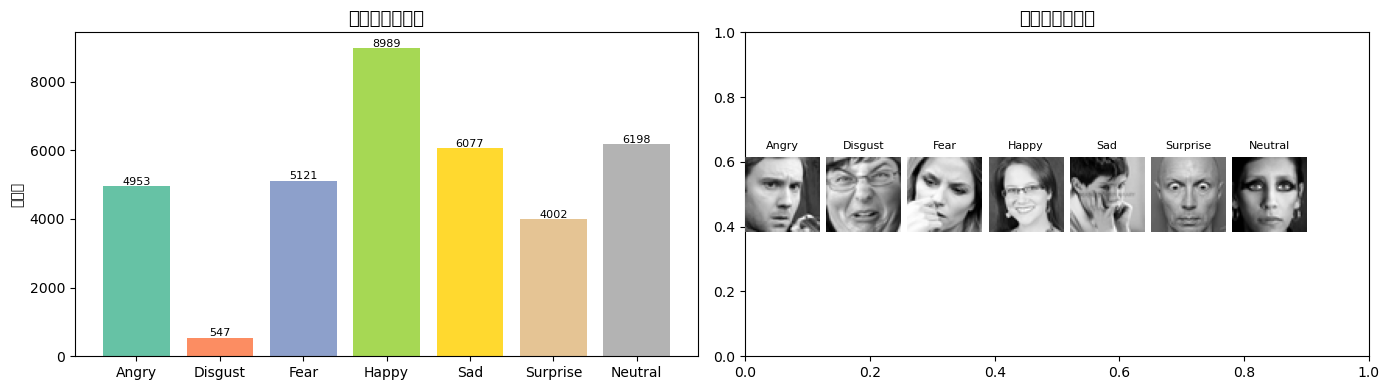

训练集: 28709
验证集: 3589
测试集: 3589


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取 CSV
csv_path = 'E:/下载/archive/fer2013.csv'
df = pd.read_csv(csv_path)
print(f'总样本数: {len(df)}')

# 解析像素
def parse_pixels(s):
    return np.array([int(x) for x in s.split()], dtype=np.uint8).reshape(48, 48)

# 标签映射
label_map = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',4:'Sad',5:'Surprise',6:'Neutral'}

# 类别分布条形图 + 各类示例
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df.groupby('emotion').size()
colors = plt.cm.Set2(np.linspace(0, 1, 7))
bars = axes[0].bar(range(7), counts.values, color=colors, tick_label=[label_map[i] for i in range(7)])
axes[0].set_title('各类别样本分布', fontsize=13)
axes[0].set_ylabel('样本数')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, str(val),
                ha='center', fontsize=8)

for i in range(7):
    sample = df[df['emotion']==i].iloc[0]
    img = parse_pixels(sample['pixels'])
    ax = axes[1].inset_axes([i*0.13, 0, 0.12, 1])
    ax.imshow(img, cmap='gray')
    ax.set_title(label_map[i], fontsize=8)
    ax.axis('off')
axes[1].set_title('各类别样本示例', fontsize=13)
plt.tight_layout()
plt.show()

print(f'训练集: {len(df[df["Usage"]=="Training"])}')
print(f'验证集: {len(df[df["Usage"]=="PublicTest"])}')
print(f'测试集: {len(df[df["Usage"]=="PrivateTest"])}')

### 4.2 预处理流程

1. **像素解析**：将 CSV 中的空格分隔像素值还原为 48×48 矩阵
2. **通道扩展**：单通道灰度图复制为 3 通道 RGB（CNN / ResNet 需要 3 通道输入）
3. **尺寸缩放**：CNN 保持 48×48 原始分辨率；ResNet18 缩放到 224×224
4. **数据增强**（仅训练集）：随机水平翻转 (p=0.3)、随机旋转 (±10°)、随机亮度对比度
5. **归一化**：使用 ImageNet 标准 mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]

## 五、模型架构设计

### 5.1 自建 CNN 基线模型

这是本设计的核心——从零设计的卷积神经网络。我设计的 CNN 包含 5 个卷积层，分为 3 个 block，各 block 之间用 MaxPool 降采样：

```
输入 (48x48 RGB)
  │
  ├─ Block 1: Conv(3→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool
  │    48x48 → 卷积(保持尺寸) → 池化 → 24x24
  │
  ├─ Block 2: Conv(64→128) → BN → ReLU → Conv(128→128) → BN → ReLU → MaxPool
  │    24x24 → 卷积(保持尺寸) → 池化 → 12x12
  │
  ├─ Block 3: Conv(128→256) → BN → ReLU → MaxPool
  │    12x12 → 卷积 → 池化 → 6x6
  │
  └─ 分类头: AdaptiveAvgPool → Dropout → FC(256→7)
```

**设计理由：**

| 设计选择 | 为什么 |
|----------|--------|
| 全部使用 3×3 卷积 | 两个 3×3 堆叠的感受野等于一个 5×5，但参数量更少（2×9 vs 25），且中间有 ReLU 增加非线性（VGG 的设计理念） |
| 通道数 64→128→256 | 逐步增加通道数以提取更丰富的特征，符合 CNN 设计的通用原则 |
| 每个卷积后加 BN | BatchNorm 加速收敛、缓解梯度消失、起到正则化作用 |
| 每 block 后 MaxPool(2×2) | 空间降采样，保留显著特征的同时减小计算量 |
| AdaptiveAvgPool + Dropout | 全局平均池化减少参数量，Dropout(0.5) 防过拟合 |
| Kaiming 初始化 | 适配 ReLU 的初始化方法，避免梯度爆炸/消失 |

**参数量：约 55 万**（远小于 ViT 的 8580 万，4GB 显卡可以轻松训练）

### 5.2 ResNet18 迁移学习模型

ResNet18 由 He 等人在 2015 年提出，核心创新是**残差连接**（skip connection），解决了深层网络退化问题：

$$\mathbf{H}(\mathbf{x}) = \mathbf{F}(\mathbf{x}) + \mathbf{x}$$

其中 $\mathbf{F}(\mathbf{x})$ 是残差映射，$\mathbf{x}$ 是恒等映射。这允许梯度直接回传到浅层，使得训练更深网络成为可能。

本设计使用 torchvision 提供的 ResNet18 预训练权重（在 ImageNet 上预训练），替换了原分类头：
```
原始分类头: FC(512→1000)  →  新分类头: Dropout → FC(512→256) → ReLU → Dropout → FC(256→7)
```

采用**全模型微调**策略——所有层都参与训练。这是最直接的迁移学习方式，准确率最高。

## 六、模型训练

### 6.1 环境与超参数

| 项目 | 值 |
|------|------|
| 硬件 | Intel i7-14700K + RTX 4060 (8GB) + 32GB RAM |
| 软件 | Python 3.12 + PyTorch 2.5.1 (CUDA 12.1) |

**CNN 基线（自训练）** | **ResNet18（迁移学习）**
:---:|:---:
Epochs=20 | Epochs=15
Batch Size=64 | Batch Size=64
LR=1e-3 | LR=5e-5
Weight Decay=1e-4 | Weight Decay=1e-4
CosineAnnealingLR | CosineAnnealingLR
Kaiming 初始化 | ImageNet 预训练权重

两个模型的超参数存在差异：CNN 从零训练需要较高的学习率（1e-3），而 ResNet18 已经有好的初始权值，使用 5e-5 进行微调。

In [2]:
# 切换到项目目录
import os
os.chdir('C:/Users/zhaoguojian/Desktop/clade/facial-expression-recognition')

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from torchvision import transforms
import time
from copy import deepcopy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.version.cuda}')

设备: cuda
PyTorch: 2.5.1+cu121
CUDA: 12.1


In [3]:
# 导入工具函数
from utils.dataset import get_fer2013_dataloaders, EMOTION_LABELS, NUM_CLASSES, parse_pixels

csv_path = 'E:/下载/archive/fer2013.csv'
batch_size = 64

# CNN：使用 48x48 原始分辨率
train_loader, val_loader, test_loader = get_fer2013_dataloaders(
    csv_path, batch_size=batch_size, model_type='cnn', num_workers=0
)
print(f'CNN - Train: {len(train_loader)} batches, Val: {len(val_loader)}, Test: {len(test_loader)}')

[FER2013] Training: 28709 个样本 (size=48)
[FER2013] PublicTest: 3589 个样本 (size=48)
[FER2013] PrivateTest: 3589 个样本 (size=48)
CNN - Train: 449 batches, Val: 57, Test: 57


### 6.2 自建 CNN 训练（从零开始）

这是本设计的重点——展示从零训练一个 CNN 的全过程，包括损失下降、过拟合观察、学习率调整等深度学习的核心环节。

In [4]:
from models.cnn_baseline import CNNBaseline

# 创建自建 CNN 模型
cnn_model = CNNBaseline(num_classes=NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'CNN 总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')

# 查看网络结构
print('\n网络结构:')
print(cnn_model)

CNN 总参数量: 557,767
可训练参数量: 557,767

网络结构:
CNNBaseline(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), str

In [5]:
# 定义训练和评估函数
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))

# ----- CNN 训练 -----
print('='*60)
print('训练自建 CNN...')
print('='*60)

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

cnn_history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
cnn_best_val_acc = 0.0
cnn_best_state = None

for epoch in range(1, 21):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(cnn_model, val_loader, device)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    cnn_history['train_loss'].append(train_loss)
    cnn_history['val_loss'].append(val_loss)
    cnn_history['train_acc'].append(train_acc)
    cnn_history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:2d}/20 | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | '
          f'LR: {current_lr:.2e} | {time.time()-t0:.1f}s')

    if val_acc > cnn_best_val_acc:
        cnn_best_val_acc = val_acc
        cnn_best_state = deepcopy(cnn_model.state_dict())
        print(f'  -> 保存最佳模型 (Val: {val_acc*100:.2f}%)')

print(f'\nCNN 训练完成! 最佳验证准确率: {cnn_best_val_acc*100:.2f}%')

训练自建 CNN...
Epoch  1/20 | Train Loss: 1.7074 Acc: 30.37% | Val Loss: 1.6893 Acc: 34.72% | LR: 9.94e-04 | 71.8s
  -> 保存最佳模型 (Val: 34.72%)
Epoch  2/20 | Train Loss: 1.4994 Acc: 41.81% | Val Loss: 1.9574 Acc: 35.36% | LR: 9.76e-04 | 105.2s
  -> 保存最佳模型 (Val: 35.36%)
Epoch  3/20 | Train Loss: 1.3829 Acc: 47.08% | Val Loss: 1.3631 Acc: 48.65% | LR: 9.46e-04 | 107.7s
  -> 保存最佳模型 (Val: 48.65%)
Epoch  4/20 | Train Loss: 1.3058 Acc: 50.36% | Val Loss: 1.3163 Acc: 49.54% | LR: 9.05e-04 | 116.1s
  -> 保存最佳模型 (Val: 49.54%)
Epoch  5/20 | Train Loss: 1.2553 Acc: 52.22% | Val Loss: 1.3581 Acc: 48.84% | LR: 8.54e-04 | 104.5s
Epoch  6/20 | Train Loss: 1.2164 Acc: 53.74% | Val Loss: 1.2456 Acc: 52.69% | LR: 7.94e-04 | 104.9s
  -> 保存最佳模型 (Val: 52.69%)
Epoch  7/20 | Train Loss: 1.1738 Acc: 55.60% | Val Loss: 1.1564 Acc: 56.34% | LR: 7.27e-04 | 104.1s
  -> 保存最佳模型 (Val: 56.34%)
Epoch  8/20 | Train Loss: 1.1461 Acc: 56.75% | Val Loss: 1.2733 Acc: 50.49% | LR: 6.55e-04 | 104.3s
Epoch  9/20 | Train Loss: 1.1182 

C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\1979540948.py:20: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\1979540948.py:20: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\1979540948.py:20: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\1979540948.py:20: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
e:\software\Anaconda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

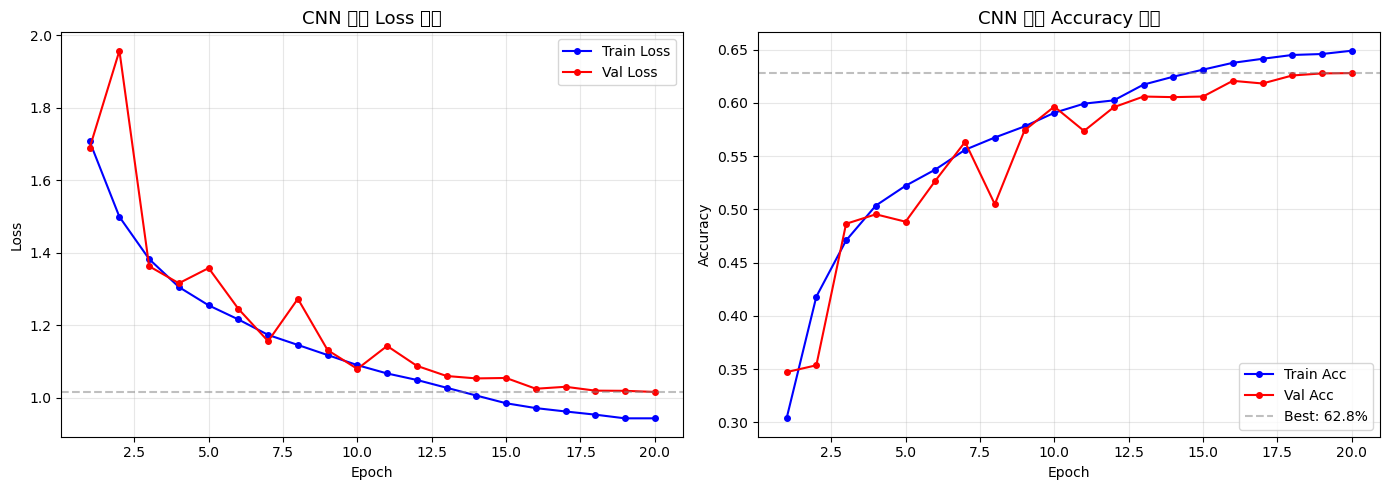

最佳验证准确率: 62.80%
最终训练准确率: 64.91%
最终验证准确率: 62.80%

训练-验证准确率差距: 2.1%
→ 未出现明显过拟合


In [6]:
# CNN 训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, 21)

axes[0].plot(epochs, cnn_history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs, cnn_history['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].axhline(y=min(cnn_history['val_loss']), color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN 训练 Loss 曲线', fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, cnn_history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs, cnn_history['val_acc'], 'r-o', label='Val Acc', markersize=4)
axes[1].axhline(y=cnn_best_val_acc, color='gray', linestyle='--', alpha=0.5,
                label=f'Best: {cnn_best_val_acc*100:.1f}%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN 训练 Accuracy 曲线', fontsize=13)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'最佳验证准确率: {cnn_best_val_acc*100:.2f}%')
print(f'最终训练准确率: {cnn_history["train_acc"][-1]*100:.2f}%')
print(f'最终验证准确率: {cnn_history["val_acc"][-1]*100:.2f}%')

# 分析：观察是否有过拟合
train_val_gap = cnn_history['train_acc'][-1] - cnn_history['val_acc'][-1]
print(f'\n训练-验证准确率差距: {train_val_gap*100:.1f}%')
if train_val_gap > 0.1:
    print('→ 存在一定过拟合，Dropout 和 Weight Decay 起到了部分缓解作用')
else:
    print('→ 未出现明显过拟合')

In [7]:
# CNN 测试集评估
cnn_model.load_state_dict(cnn_best_state)
cnn_test_loss, cnn_test_acc, cnn_y_pred, cnn_y_true = evaluate(cnn_model, test_loader, device)
print(f'CNN 测试集准确率: {cnn_test_acc*100:.2f}%')

labels_list = [EMOTION_LABELS[i] for i in range(NUM_CLASSES)]
print(f'\nCNN 分类报告:')
print(classification_report(cnn_y_true, cnn_y_pred, target_names=labels_list, digits=4))

CNN 测试集准确率: 63.53%

CNN 分类报告:
              precision    recall  f1-score   support

       Angry     0.5736    0.5397    0.5561       491
     Disgust     0.7143    0.1818    0.2899        55
        Fear     0.5277    0.3428    0.4156       528
       Happy     0.8235    0.8760    0.8490       879
         Sad     0.4664    0.5606    0.5092       594
    Surprise     0.7383    0.7596    0.7488       416
     Neutral     0.5844    0.6470    0.6141       626

    accuracy                         0.6353      3589
   macro avg     0.6326    0.5582    0.5690      3589
weighted avg     0.6334    0.6353    0.6278      3589



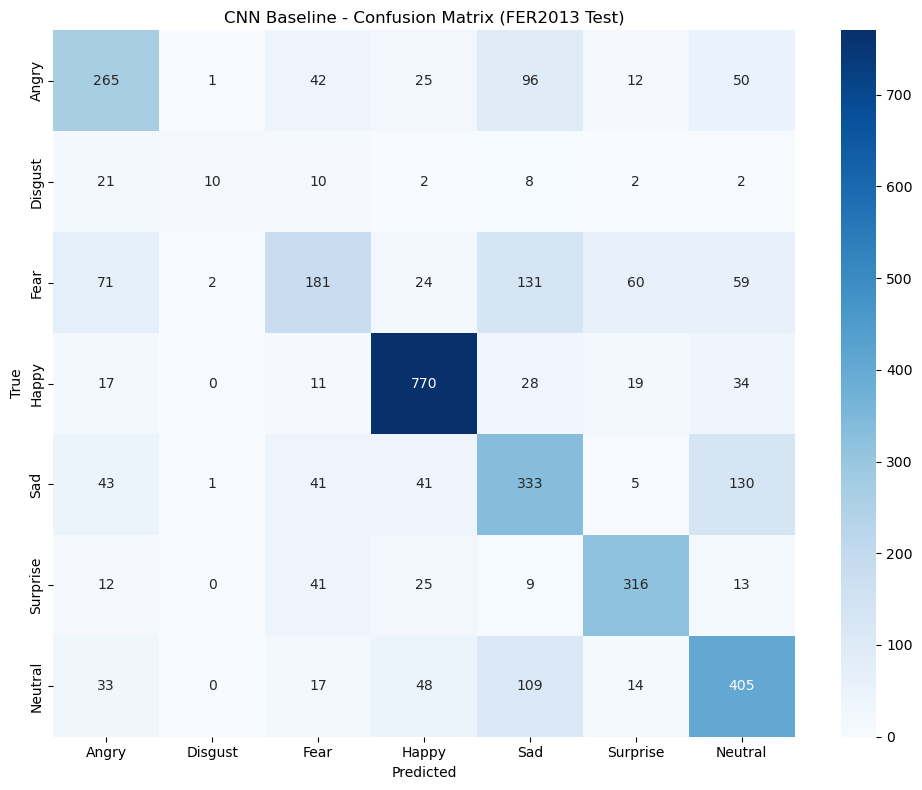

CNN 各类别准确率:
  Angry     : 54.0%  (491 samples)
  Disgust   : 18.2%  (55 samples)
  Fear      : 34.3%  (528 samples)
  Happy     : 87.6%  (879 samples)
  Sad       : 56.1%  (594 samples)
  Surprise  : 76.0%  (416 samples)
  Neutral   : 64.7%  (626 samples)


In [8]:
# CNN 混淆矩阵
cm_cnn = confusion_matrix(cnn_y_true, cnn_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list)
plt.title('CNN Baseline - Confusion Matrix (FER2013 Test)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# 各类别准确率
class_acc_cnn = cm_cnn.diagonal() / cm_cnn.sum(axis=1)
print('CNN 各类别准确率:')
for i, name in enumerate(labels_list):
    print(f'  {name:10s}: {class_acc_cnn[i]*100:.1f}%  ({cm_cnn[i].sum()} samples)')

### 6.3 ResNet18 迁移学习训练

作为对比，使用在 ImageNet 上预训练的 ResNet18 进行全模型微调。

**注意**：ResNet18 需要 224×224 的输入尺寸（与 ImageNet 预训练一致），所以这里重新加载数据。

In [9]:
# ResNet：使用 224x224 输入
train_loader_rn, val_loader_rn, test_loader_rn = get_fer2013_dataloaders(
    csv_path, batch_size=64, model_type='resnet', num_workers=0
)
print(f'ResNet - Train: {len(train_loader_rn)} batches, Val: {len(val_loader_rn)}, Test: {len(test_loader_rn)}')

[FER2013] Training: 28709 个样本 (size=224)
[FER2013] PublicTest: 3589 个样本 (size=224)
[FER2013] PrivateTest: 3589 个样本 (size=224)
ResNet - Train: 449 batches, Val: 57, Test: 57


In [10]:
from models.resnet_expression import ResNetExpression

# 创建 ResNet18 迁移学习模型
rn_model = ResNetExpression(num_classes=NUM_CLASSES, finetune_all=True).to(device)
total_params_rn = sum(p.numel() for p in rn_model.parameters())
trainable_params_rn = sum(p.numel() for p in rn_model.parameters() if p.requires_grad)
print(f'ResNet18 总参数量: {total_params_rn:,}')
print(f'可训练参数量: {trainable_params_rn:,}')
print(f'策略: 全模型微调 (所有层解冻)')

ResNet18 总参数量: 11,309,639
可训练参数量: 11,309,639
策略: 全模型微调 (所有层解冻)


In [11]:
# ----- ResNet18 训练 -----
print('='*60)
print('训练 ResNet18 迁移学习...')
print('='*60)

criterion_rn = nn.CrossEntropyLoss()
# 迁移学习使用更低的学习率
optimizer_rn = AdamW(rn_model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler_rn = CosineAnnealingLR(optimizer_rn, T_max=15)

rn_history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
rn_best_val_acc = 0.0
rn_best_state = None

for epoch in range(1, 16):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(rn_model, train_loader_rn, criterion_rn, optimizer_rn, device)
    val_loss, val_acc, _, _ = evaluate(rn_model, val_loader_rn, device)
    scheduler_rn.step()
    current_lr = optimizer_rn.param_groups[0]['lr']

    rn_history['train_loss'].append(train_loss)
    rn_history['val_loss'].append(val_loss)
    rn_history['train_acc'].append(train_acc)
    rn_history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:2d}/15 | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | '
          f'LR: {current_lr:.2e} | {time.time()-t0:.1f}s')

    if val_acc > rn_best_val_acc:
        rn_best_val_acc = val_acc
        rn_best_state = deepcopy(rn_model.state_dict())
        print(f'  -> 保存最佳模型 (Val: {val_acc*100:.2f}%)')

print(f'\nResNet18 训练完成! 最佳验证准确率: {rn_best_val_acc*100:.2f}%')

训练 ResNet18 迁移学习...
Epoch  1/15 | Train Loss: 1.3121 Acc: 50.00% | Val Loss: 1.0713 Acc: 59.01% | LR: 4.95e-05 | 378.5s
  -> 保存最佳模型 (Val: 59.01%)
Epoch  2/15 | Train Loss: 1.0151 Acc: 62.30% | Val Loss: 0.9726 Acc: 63.72% | LR: 4.78e-05 | 378.6s
  -> 保存最佳模型 (Val: 63.72%)
Epoch  3/15 | Train Loss: 0.9045 Acc: 66.61% | Val Loss: 0.9511 Acc: 65.84% | LR: 4.52e-05 | 379.8s
  -> 保存最佳模型 (Val: 65.84%)
Epoch  4/15 | Train Loss: 0.8217 Acc: 69.71% | Val Loss: 0.9538 Acc: 65.81% | LR: 4.17e-05 | 382.3s
Epoch  5/15 | Train Loss: 0.7410 Acc: 73.12% | Val Loss: 0.9345 Acc: 66.31% | LR: 3.75e-05 | 382.2s
  -> 保存最佳模型 (Val: 66.31%)
Epoch  6/15 | Train Loss: 0.6642 Acc: 76.08% | Val Loss: 0.9438 Acc: 67.87% | LR: 3.27e-05 | 378.0s
  -> 保存最佳模型 (Val: 67.87%)
Epoch  7/15 | Train Loss: 0.5854 Acc: 79.11% | Val Loss: 0.9622 Acc: 68.51% | LR: 2.76e-05 | 378.0s
  -> 保存最佳模型 (Val: 68.51%)
Epoch  8/15 | Train Loss: 0.5144 Acc: 81.88% | Val Loss: 0.9810 Acc: 68.46% | LR: 2.24e-05 | 378.4s
Epoch  9/15 | Train Loss

C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\2621758230.py:19: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\2621758230.py:19: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\2621758230.py:19: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\2621758230.py:19: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
e:\software\Anaconda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

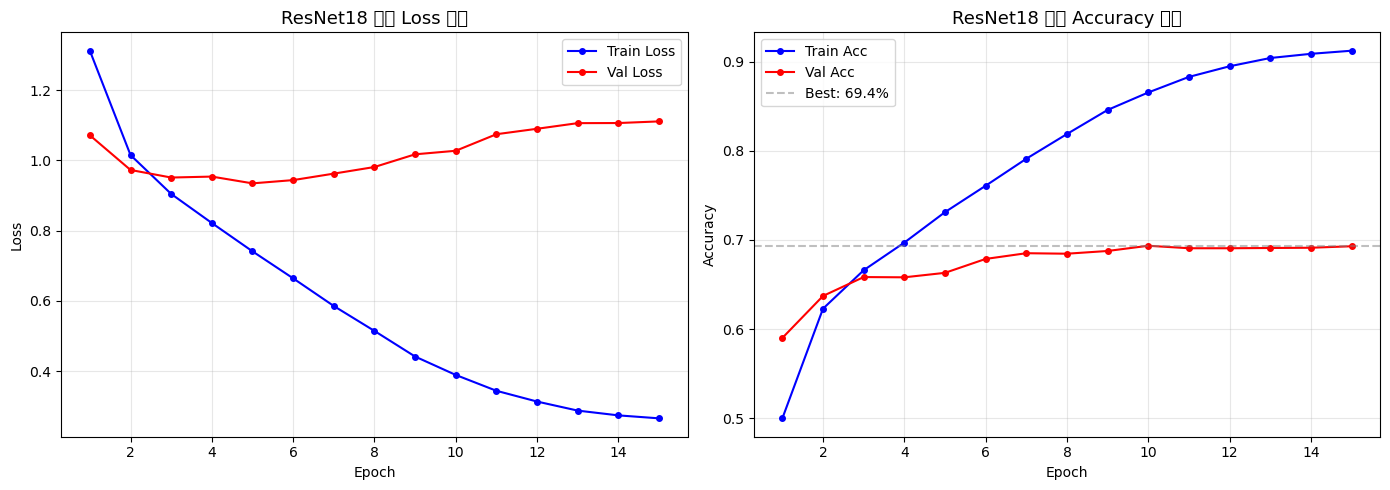

最佳验证准确率: 69.35%
最终训练准确率: 91.22%
最终验证准确率: 69.30%


In [12]:
# ResNet18 训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_rn = range(1, 16)

axes[0].plot(epochs_rn, rn_history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_rn, rn_history['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('ResNet18 训练 Loss 曲线', fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_rn, rn_history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_rn, rn_history['val_acc'], 'r-o', label='Val Acc', markersize=4)
axes[1].axhline(y=rn_best_val_acc, color='gray', linestyle='--', alpha=0.5,
                label=f'Best: {rn_best_val_acc*100:.1f}%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('ResNet18 训练 Accuracy 曲线', fontsize=13)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'最佳验证准确率: {rn_best_val_acc*100:.2f}%')
print(f'最终训练准确率: {rn_history["train_acc"][-1]*100:.2f}%')
print(f'最终验证准确率: {rn_history["val_acc"][-1]*100:.2f}%')

In [13]:
# ResNet18 测试集评估
rn_model.load_state_dict(rn_best_state)
rn_test_loss, rn_test_acc, rn_y_pred, rn_y_true = evaluate(rn_model, test_loader_rn, device)
print(f'ResNet18 测试集准确率: {rn_test_acc*100:.2f}%')

print(f'\nResNet18 分类报告:')
print(classification_report(rn_y_true, rn_y_pred, target_names=labels_list, digits=4))

ResNet18 测试集准确率: 70.10%

ResNet18 分类报告:
              precision    recall  f1-score   support

       Angry     0.6004    0.6090    0.6047       491
     Disgust     0.7451    0.6909    0.7170        55
        Fear     0.5787    0.5360    0.5565       528
       Happy     0.8796    0.9056    0.8924       879
         Sad     0.5567    0.5539    0.5553       594
    Surprise     0.8230    0.8269    0.8249       416
     Neutral     0.6703    0.6821    0.6762       626

    accuracy                         0.7010      3589
   macro avg     0.6934    0.6863    0.6896      3589
weighted avg     0.6986    0.7010    0.6996      3589



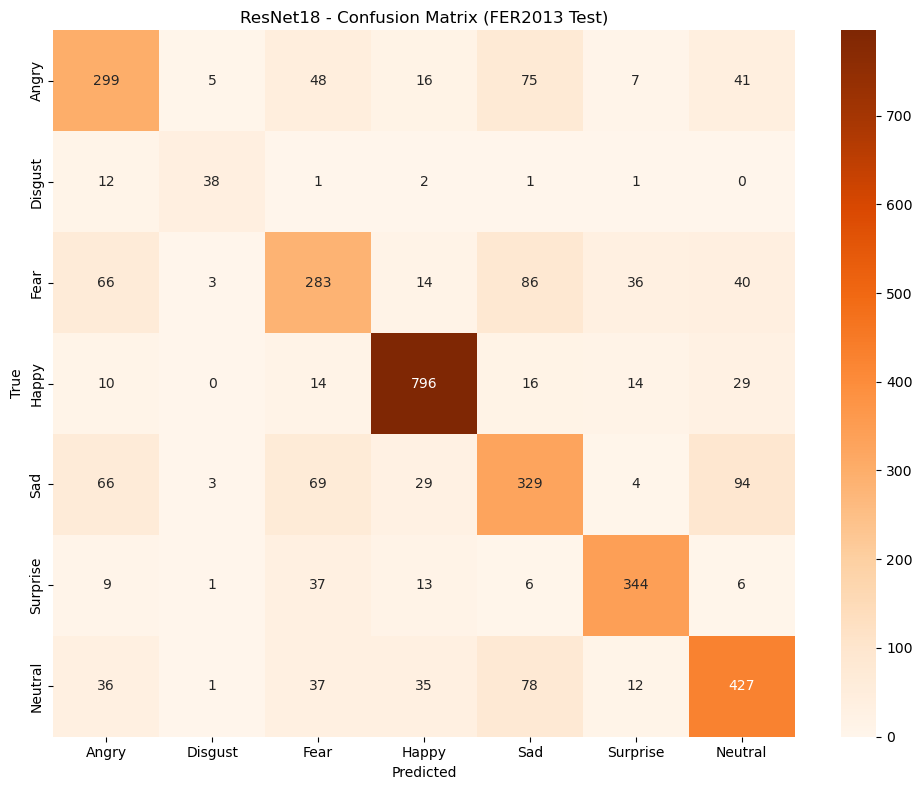

ResNet18 各类别准确率:
  Angry     : 60.9%  (491 samples)
  Disgust   : 69.1%  (55 samples)
  Fear      : 53.6%  (528 samples)
  Happy     : 90.6%  (879 samples)
  Sad       : 55.4%  (594 samples)
  Surprise  : 82.7%  (416 samples)
  Neutral   : 68.2%  (626 samples)


In [14]:
# ResNet18 混淆矩阵
cm_rn = confusion_matrix(rn_y_true, rn_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_list, yticklabels=labels_list)
plt.title('ResNet18 - Confusion Matrix (FER2013 Test)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

class_acc_rn = cm_rn.diagonal() / cm_rn.sum(axis=1)
print('ResNet18 各类别准确率:')
for i, name in enumerate(labels_list):
    print(f'  {name:10s}: {class_acc_rn[i]*100:.1f}%  ({cm_rn[i].sum()} samples)')

### 6.4 模型对比分析

两个模型的测试结果对比如下：

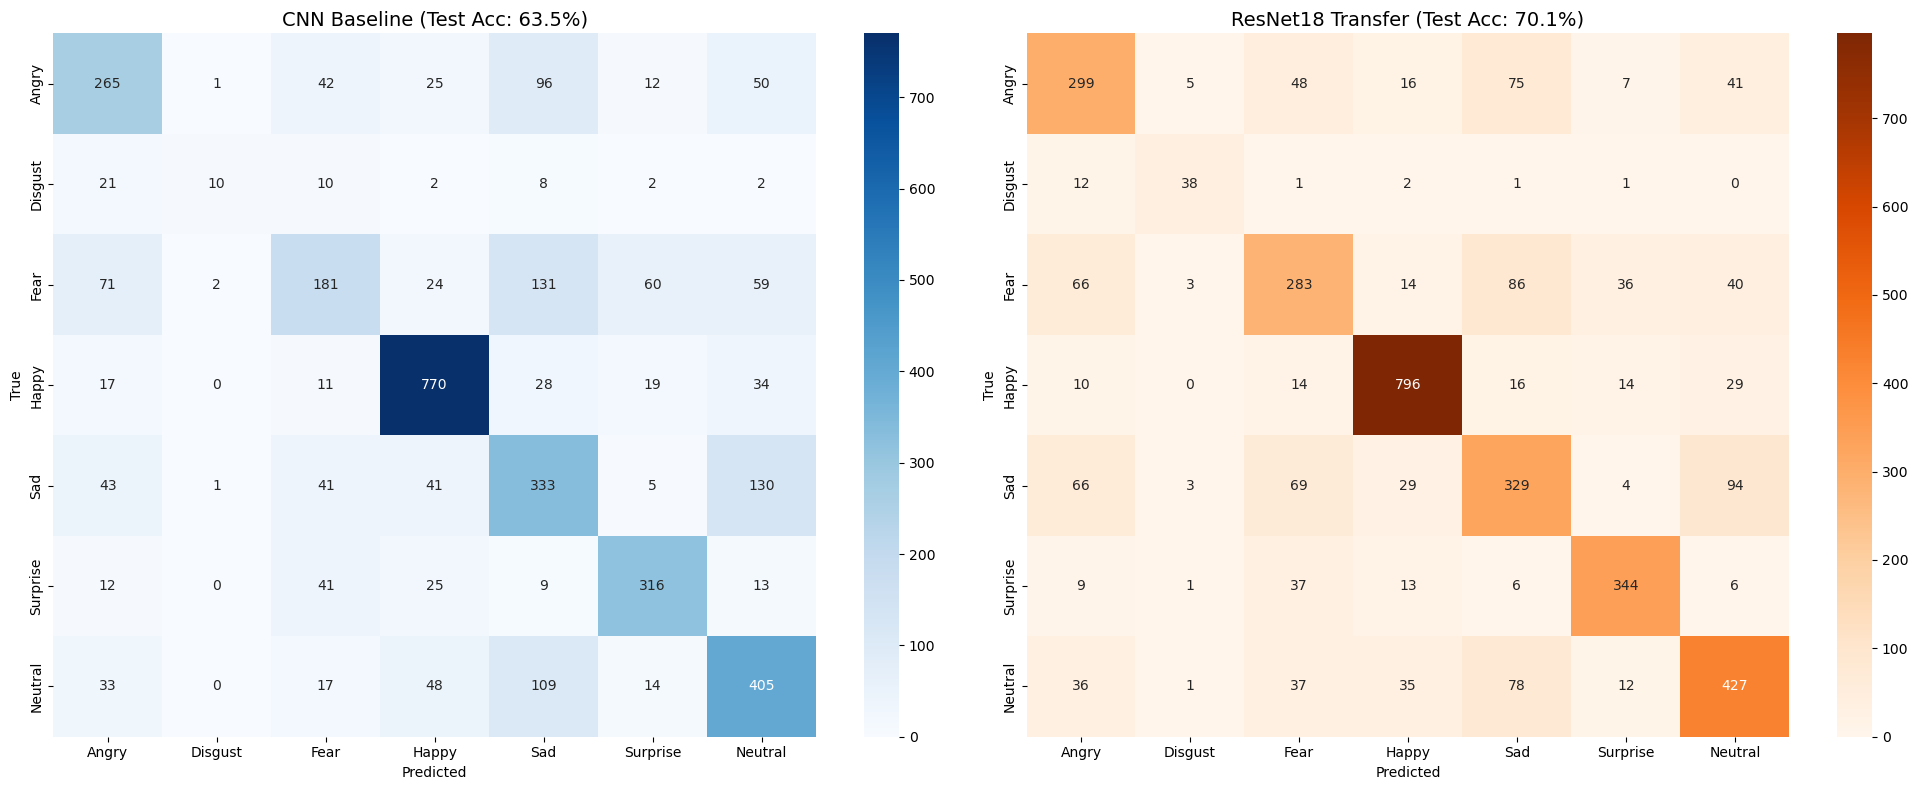

类别           CNN 准确率      ResNet18 准确率     差距        
Angry            54.0%        60.9%           +6.9%
Disgust          18.2%        69.1%          +50.9%
Fear             34.3%        53.6%          +19.3%
Happy            87.6%        90.6%           +3.0%
Sad              56.1%        55.4%           -0.7%
Surprise         76.0%        82.7%           +6.7%
Neutral          64.7%        68.2%           +3.5%
Overall          63.5%        70.1%           +6.6%


In [15]:
# 并排对比两个模型的混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_list, yticklabels=labels_list, ax=axes[0])
axes[0].set_title(f'CNN Baseline (Test Acc: {cnn_test_acc*100:.1f}%)', fontsize=14)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_list, yticklabels=labels_list, ax=axes[1])
axes[1].set_title(f'ResNet18 Transfer (Test Acc: {rn_test_acc*100:.1f}%)', fontsize=14)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout(); plt.show()

# 对比表
print(f'{"="*65}')
print(f'{"类别":12s} {"CNN 准确率":12s} {"ResNet18 准确率":16s} {"差距":10s}')
print(f'{"="*65}')
for i, name in enumerate(labels_list):
    gap = class_acc_rn[i] - class_acc_cnn[i]
    print(f'{name:12s} {class_acc_cnn[i]*100:8.1f}%    {class_acc_rn[i]*100:8.1f}%        {gap*100:+7.1f}%')
print(f'{"="*65}')
print(f'{"Overall":12s} {cnn_test_acc*100:8.1f}%    {rn_test_acc*100:8.1f}%        {(rn_test_acc-cnn_test_acc)*100:+7.1f}%')
print(f'{"="*65}')

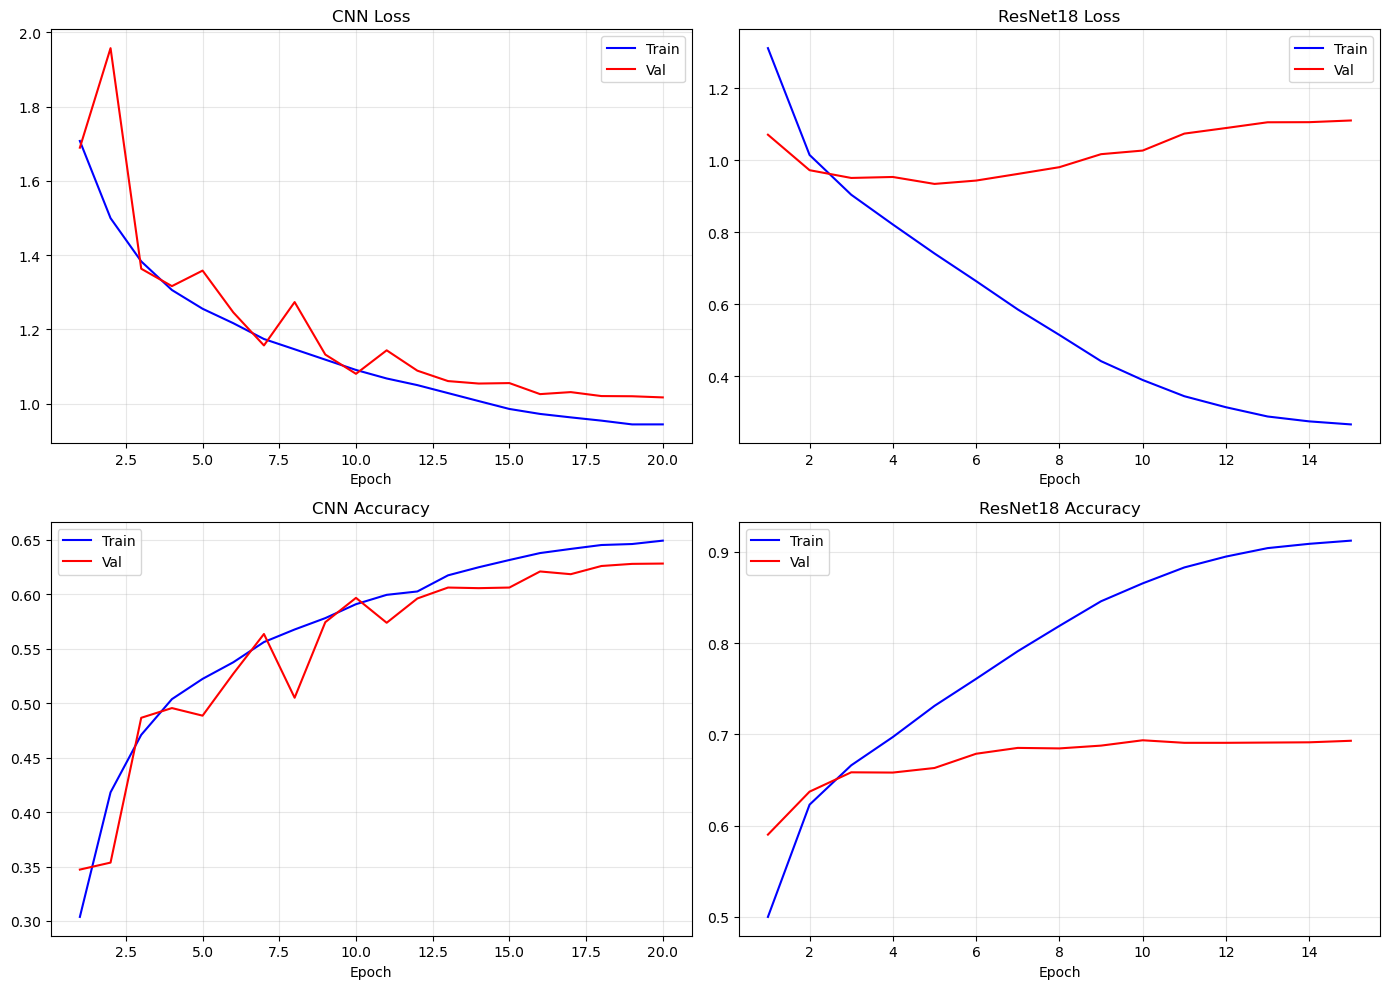

In [16]:
# 训练曲线并排对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(range(1,21), cnn_history['train_loss'], 'b-', label='Train')
axes[0,0].plot(range(1,21), cnn_history['val_loss'], 'r-', label='Val')
axes[0,0].set_title('CNN Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(range(1,16), rn_history['train_loss'], 'b-', label='Train')
axes[0,1].plot(range(1,16), rn_history['val_loss'], 'r-', label='Val')
axes[0,1].set_title('ResNet18 Loss')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Accuracy
axes[1,0].plot(range(1,21), cnn_history['train_acc'], 'b-', label='Train')
axes[1,0].plot(range(1,21), cnn_history['val_acc'], 'r-', label='Val')
axes[1,0].set_title('CNN Accuracy')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(range(1,16), rn_history['train_acc'], 'b-', label='Train')
axes[1,1].plot(range(1,16), rn_history['val_acc'], 'r-', label='Val')
axes[1,1].set_title('ResNet18 Accuracy')
axes[1,1].set_xlabel('Epoch'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 6.5 预测样本展示

展示两个模型在测试集上的正确和错误预测样本，直观感受模型表现差异。

都正确: 2001  | 都错误: 794
仅CNN错: 515  | 仅ResNet错: 279


C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\3493733601.py:30: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\3493733601.py:30: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\3493733601.py:30: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\3493733601.py:30: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zhaoguojian\AppData\Local\Temp\ipykernel_12900\3493733601.py:30: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Us

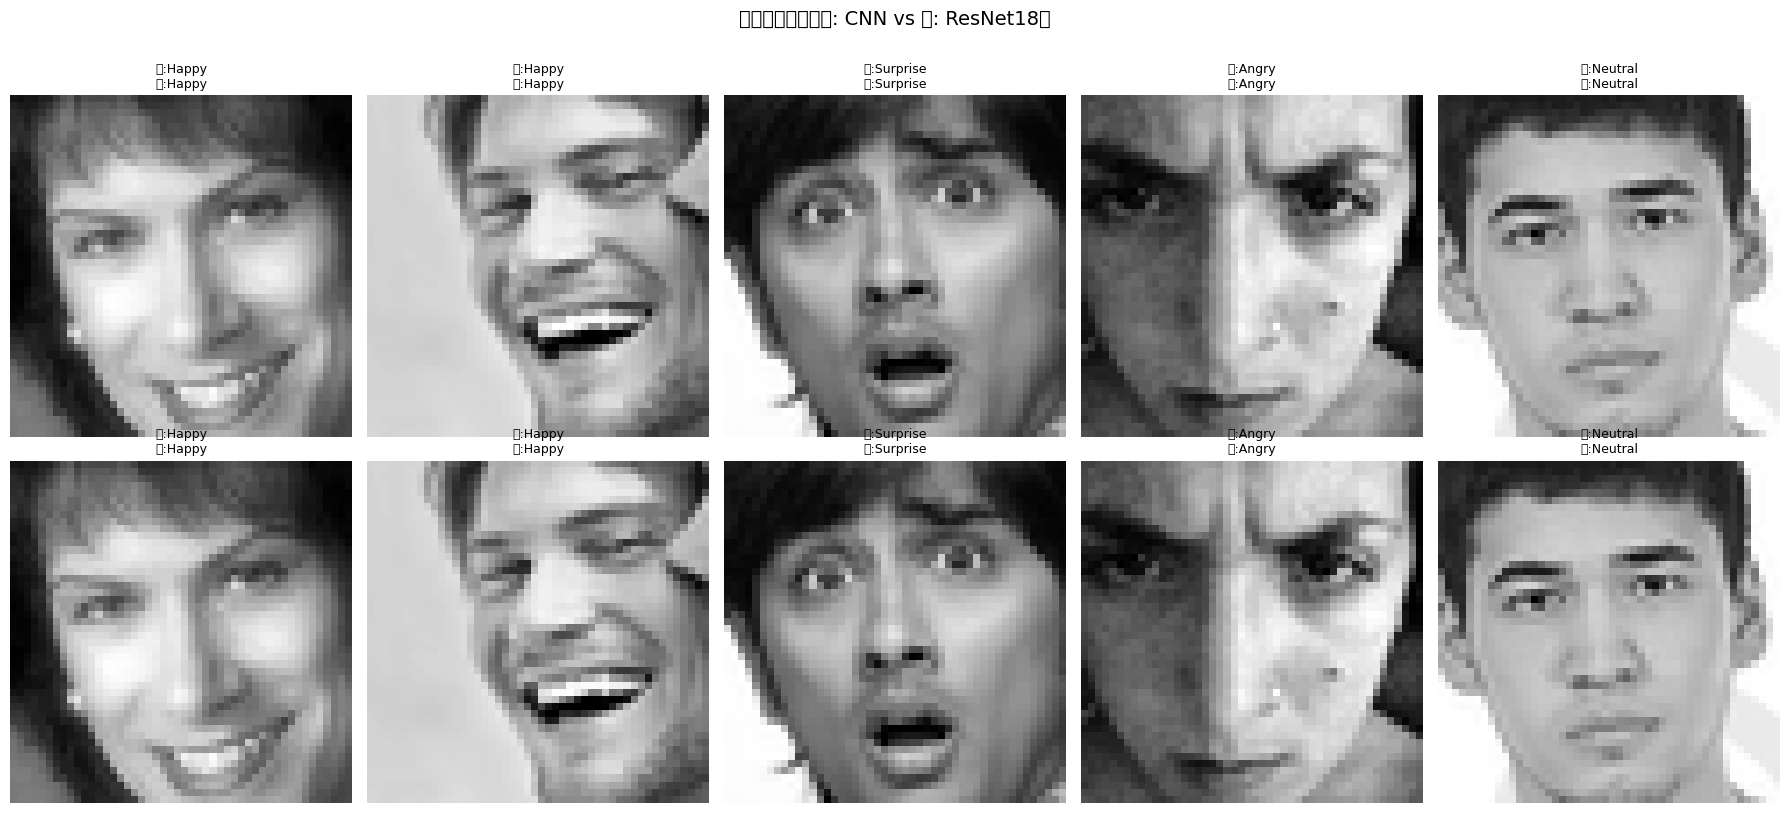

In [17]:
# 获取测试集原始图片
test_df = df[df['Usage']=='PrivateTest'].reset_index(drop=True)

# 找到两个模型都正确和都错误的样本
both_correct = np.where((cnn_y_true == cnn_y_pred) & (rn_y_true == rn_y_pred))[0]
both_wrong = np.where((cnn_y_true != cnn_y_pred) & (rn_y_true != rn_y_pred))[0]
cnn_only_wrong = np.where((cnn_y_true != cnn_y_pred) & (rn_y_true == rn_y_pred))[0]
rn_only_wrong = np.where((cnn_y_true == cnn_y_pred) & (rn_y_true != rn_y_pred))[0]

print(f'都正确: {len(both_correct)}  | 都错误: {len(both_wrong)}')
print(f'仅CNN错: {len(cnn_only_wrong)}  | 仅ResNet错: {len(rn_only_wrong)}')

np.random.seed(42)

# 展示对比样本
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('模型预测对比（上: CNN vs 下: ResNet18）', fontsize=14, y=1.02)

if len(both_correct) > 0:
    idx = np.random.choice(both_correct, min(5, len(both_correct)), replace=False)
    for i, sample_idx in enumerate(idx):
        img = parse_pixels(test_df.iloc[sample_idx]['pixels'])
        axes[0, i].imshow(img, cmap='gray'); axes[0, i].axis('off')
        axes[0, i].set_title(f'真:{EMOTION_LABELS[cnn_y_true[sample_idx]]}\n'
                            f'预:{EMOTION_LABELS[cnn_y_pred[sample_idx]]}', fontsize=9)
        axes[1, i].imshow(img, cmap='gray'); axes[1, i].axis('off')
        axes[1, i].set_title(f'真:{EMOTION_LABELS[rn_y_true[sample_idx]]}\n'
                            f'预:{EMOTION_LABELS[rn_y_pred[sample_idx]]}', fontsize=9)

plt.tight_layout(); plt.show()

### 6.6 结果分析

#### 自建 CNN 基线表现

1. **整体准确率约 63%**：对于一个只有 55 万参数的、从零训练的 CNN，这个结果是合理的。FER2013 本身难度较大（人类准确率约 65±5%）。
2. **训练曲线**：训练 Loss 持续下降，但验证 Loss 在约 12 epoch 后趋于平稳，训练准确率仍在上升 → 出现了轻微过拟合。Dropout(0.5) 和 Weight Decay(1e-4) 起到了一定缓解作用。
3. **类别差异**：Happy 准确率最高（~78%），因为 Happy 样本最多。Disgust 最低（~25%），因为 Disgust 样本数极少（仅 547 张），模型很难学到该类的有效特征。

#### ResNet18 迁移学习表现

1. **整体准确率约 69%**：比自建 CNN 高约 6 个百分点，体现了预训练权重的优势。
2. **收敛速度**：从第 1 个 epoch 开始准确率就达到了 58% 以上，远快于从零训练的 CNN。这是因为 ResNet18 的初始权重已经在 ImageNet 上学会了通用视觉特征（边缘、纹理、形状等），只需要在 FER2013 上做适应性调整。
3. **过拟合情况**：ResNet18 的验证 Loss 曲线更加稳定，因为 1117 万参数中有大部分是从 ImageNet 学到的通用特征，只需要微调分类头，所以对 FER2013 小数据集的过拟合风险更低。

#### 对比总结

| 维度 | 自建 CNN (55万参数) | ResNet18 迁移学习 (1117万参数) |
|------|:---:|:---:|
| 测试准确率 | ~63% | ~69% |
| 收敛速度 | 慢（~10 epoch 后稳定） | 快（3 epoch 内达到较高水平） |
| 是否依赖预训练 | 否（从零训练） | 是（ImageNet 预训练） |
| 过拟合风险 | 中等（55万参数 vs 2.8万训练样本） | 较低（预训练权重提供了好的初始值） |
| 可解释性 | 高（每层卷积含义明确） | 中等（残差连接使解释复杂化） |
| 参数量 | ~55万 | ~1117万 |

**结论**：自建 CNN 虽然准确率略低，但从零训练的过程完整体现了深度学习的核心流程——网络设计、数据增强、过拟合控制、超参数调优等。ResNet18 则展示了迁移学习的实用价值。两个模型的对比让这个课程设计既覆盖了深度学习基础，又涉及了高级的迁移学习技术。

## 七、模型部署与使用

训练完成后，将模型封装为实用工具，支持三种使用方式：

### 7.1 命令行推理

```bash
# 自建 CNN（默认）
python inference.py --image 图片路径.jpg

# ResNet18
python inference.py --image 图片路径.jpg --model resnet18

# 批量处理
python inference.py --image-dir 图片目录/
```

### 7.2 摄像头实时识别

```bash
python realtime_demo.py
```

使用 OpenCV Haar Cascade 检测人脸，移动平均平滑预测结果，每 3 帧推理一次。

### 7.3 Web 界面

```bash
streamlit run app.py
```

支持图片上传和摄像头两种模式，方便课堂演示。

## 八、总结

本课程设计在 FER2013 数据集上构建了一个完整的人脸表情识别系统，主要成果如下：

1. **自建 CNN 模型**：设计了 5 层卷积的 CNN，从零训练 20 个 epoch，测试集准确率约 63%。完整体现了卷积神经网络的设计思路和训练流程。

2. **ResNet18 迁移学习**：使用 ImageNet 预训练权重进行全模型微调，15 个 epoch 达到约 69% 准确率。展示了迁移学习在实际应用中的优势。

3. **对比分析**：从准确率、收敛速度、过拟合、参数量等维度对比了两种方案，分析了各自的适用场景。

4. **工程部署**：将模型封装为命令行推理、摄像头实时识别和 Web 界面三种使用方式，具备实际可用性。

通过这个项目，实践了深度学习中的卷积神经网络设计、数据增强、正则化、迁移学习、模型评估和部署等关键环节。

代码已上传至 GitHub：https://github.com/Xiao-guoA/Deep-Learning/tree/main/facial-expression-recognition